device: cuda


100%|██████████| 170M/170M [00:10<00:00, 16.0MB/s]


train subset size: 50000


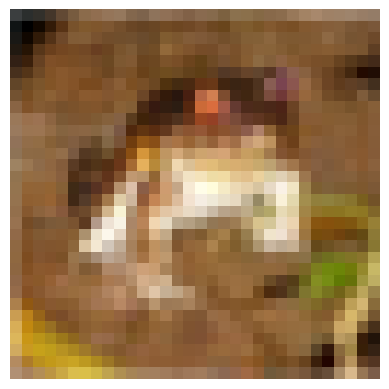

tensor([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]], device='cuda:0')


In [2]:
# @title Data Loader
import torch
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# -----------------------------
# 1) Data (RANDOM subset)
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    #transforms.Normalize((0.1307,), (0.3081,))
])


def load_ds(train_ds, test_ds, tiny_train=True):
    # ----- KEY PART: RANDOM SUBSET -----
    N_TRAIN = 1024  # size of subset

    # make it reproducible for teaching (change/remove seed if you want new samples)
    random.seed(42)

    if tiny_train:
        all_indices = list(range(len(train_full)))
        random.shuffle(all_indices)
        subset_indices = all_indices[:N_TRAIN]

        train_ds = Subset(train_full, subset_indices)

    batch_size = 32
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

    example_img = train_ds[0][0].to(device)
    example_expected = torch.nn.functional.one_hot(torch.tensor(train_ds[0][1]), num_classes=10).float().unsqueeze(0).to(device)

    print("train subset size:", len(train_ds))

    plt.figure()
    try:
        plt.imshow(example_img.cpu().squeeze(), cmap="gray")
    except:
        plt.imshow(example_img.cpu().squeeze().permute(1, 2, 0))
    plt.axis("off")
    plt.show()

    print(example_expected)

    return train_loader, test_loader, example_img, example_expected

#train_full = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
#test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_full = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_ds = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

train_loader, test_loader, example_img, example_expected = load_ds(train_full, test_ds, tiny_train=False)

In [19]:
# @title Feed-Forward Neural Network

import torch.nn as nn
import torch.nn.functional as F

class FFN(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(3 * 32 * 32, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 256)
        self.fc4 = nn.Linear(256, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        logits = self.fc4(x)
        return logits

In [20]:
# @title Feed-Forward Neural Network with Dropout

import torch.nn as nn
import torch.nn.functional as F

class D_FFN(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(3 * 32 * 32, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 256)
        self.fc4 = nn.Linear(256, 10)

        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.dropout(x)
        logits = self.fc4(x)
        return logits

In [21]:
# @title Convolutional Neural Network

import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # ----- Convolutional block -----
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)

        # ----- Fully connected block -----
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        # Conv block
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        x = self.flatten(x)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        logits = self.fc3(x)

        return logits

In [28]:
# @title Evaluation Function: [loader, model, device='cpu', flatten=False]
@torch.no_grad()
def evaluate(loader, model, device='cpu', flatten=False):
    total_loss, correct, seen = 0.0, 0, 0
    for x, y in loader:
        if flatten:
            x_test = torch.flatten(x.squeeze(1).to(device), start_dim=1)
        else:
            x_test = x.to(device)

        y_test = torch.nn.functional.one_hot(y, num_classes=10).float().to(device)

        logits = model.forward(x_test)
        loss = F.cross_entropy(logits, y_test)
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y_test.argmax(dim=1)).sum().item()
        seen += x.size(0)

    return total_loss / seen, correct / seen

In [47]:
# @title Training Function: [model, train_loader, test_loader, flatten=True, epochs=25, lr=0.001, verbose=True]

def train(model, train_loader, test_loader, flatten=True, epochs=25, lr=0.001, verbose=True):
    epochs = epochs
    lr = lr

    train_losses, train_accs = [], []
    test_losses, test_accs = [], []
    example_losses = []


    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(1, epochs + 1):
        total_loss, correct, seen = 0.0, 0, 0

        batch_losses, batch_accs = [], []
        for x_train, y_train in train_loader:
            if flatten:
                x_train = torch.flatten(x_train.squeeze(1).to(device), start_dim=1)
            else:
                x_train = x_train.to(device)

            y_train = torch.nn.functional.one_hot(y_train, num_classes=10).float().to(device)

            logits = model.forward(x_train)

            loss = F.cross_entropy(logits, y_train)
            batch_losses.append(loss)

            # Differentiate L with respect to w
            loss.backward()

            # Update our weights
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

            batch_accs.append((logits.argmax(dim=1) == y_train.argmax(dim=1)).float().mean().item())

        model.eval()
        train_losses.append(torch.mean(torch.Tensor(batch_losses)))
        train_accs.append(torch.mean(torch.Tensor(batch_accs)))
        te_loss, te_acc = evaluate(test_loader, model, device, flatten)
        test_losses.append(te_loss)
        test_accs.append(te_acc)
        model.train()

        if verbose and epoch % 5 == 0:
            print(f"[epoch {epoch:02d}]:")
            print(f"\t* TRAIN: loss={train_losses[-1]:.4f} acc={train_accs[-1]*100:.2f}%")
            print(f"\t* TEST: loss={te_loss:.4f} acc={te_acc*100:.2f}%")

    return train_losses, train_accs, test_losses, test_accs

In [48]:
models = {'FFN': {'model': FFN(), 'color': 'red'},
          'D_FFN': {'model': D_FFN(), 'color': 'blue'},
          'CNN': {'model': CNN(), 'color': 'green'}}

for model_name, model_contents in models.items():
    print('Training', model_name)
    model = model_contents['model']
    model.to(device)

    if model_name == 'CNN':
        train_losses, train_accs, test_losses, test_accs = train(model, train_loader, test_loader, flatten=False)
    else:
        train_losses, train_accs, test_losses, test_accs = train(model, train_loader, test_loader, flatten=True)

    model_contents['train_losses'] = train_losses
    model_contents['train_accs'] = train_accs
    model_contents['test_losses'] = test_losses
    model_contents['test_accs'] = test_accs

Training FFN
[epoch 05]:
	* TRAIN: loss=1.5005 acc=45.85%
	* TEST: loss=1.4964 acc=46.79%
[epoch 10]:
	* TRAIN: loss=1.3552 acc=51.38%
	* TEST: loss=1.4482 acc=48.58%
[epoch 15]:
	* TRAIN: loss=1.2566 acc=54.57%
	* TEST: loss=1.4515 acc=50.03%
[epoch 20]:
	* TRAIN: loss=1.1643 acc=58.03%
	* TEST: loss=1.4818 acc=49.98%
[epoch 25]:
	* TRAIN: loss=1.0882 acc=60.55%
	* TEST: loss=1.5329 acc=49.17%
Training D_FFN
[epoch 05]:
	* TRAIN: loss=1.7247 acc=37.70%
	* TEST: loss=1.6732 acc=40.40%
[epoch 10]:
	* TRAIN: loss=1.6605 acc=40.07%
	* TEST: loss=1.5914 acc=42.59%
[epoch 15]:
	* TRAIN: loss=1.6272 acc=41.60%
	* TEST: loss=1.5637 acc=43.75%
[epoch 20]:
	* TRAIN: loss=1.6073 acc=42.34%
	* TEST: loss=1.5602 acc=44.43%
[epoch 25]:
	* TRAIN: loss=1.5904 acc=42.88%
	* TEST: loss=1.5254 acc=46.37%
Training CNN
[epoch 05]:
	* TRAIN: loss=0.6077 acc=78.58%
	* TEST: loss=0.8543 acc=71.88%
[epoch 10]:
	* TRAIN: loss=0.1995 acc=92.96%
	* TEST: loss=1.3587 acc=70.51%
[epoch 15]:
	* TRAIN: loss=0.1032 a

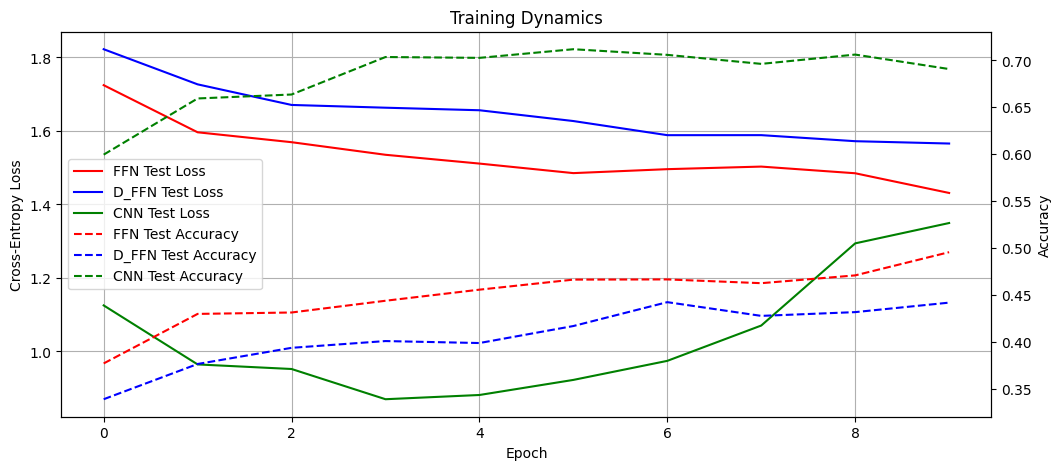

In [46]:
# @title Training Dynamics Grapher
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,5))
ax2 = ax1.twinx()

for model_name, model_contents in models.items():
    ax1.plot(model_contents['test_losses'], label=f"{model_name} Test Loss", color=model_contents['color'])
    ax2.plot(model_contents['test_accs'], label=f"{model_name} Test Accuracy", linestyle="dashed", color=model_contents['color'])

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.grid(True)
ax2.set_ylabel("Accuracy")

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="center left")

plt.title("Training Dynamics")
plt.show()